In [8]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.linalg import svd

In [9]:
# Loading the dataset and preprocessing

data_dir = r"C:\Users\NEERAV\OneDrive\Desktop\project\grayfaces"

image_vectors = []
labels = []

IMG_HEIGHT, IMG_WIDTH = 112, 92

for filename in sorted(os.listdir(data_dir)):
    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        # Split filename like "female.anpage.1.jpg" -> label is "anpage"
        parts = filename.split('.')
        person_name = parts[1] if len(parts) >= 3 else parts[0]
        
        img_path = os.path.join(data_dir, filename)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        if img is not None:
            # Resize and flatten to 1D vector of length (IMG_HEIGHT * IMG_WIDTH)
            img_resized = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
            image_vectors.append(img_resized.flatten())
            labels.append(person_name)

# Convert to arrays: X shape is (Total_Images, N^2)
X = np.array(image_vectors, dtype=np.float32)
y = np.array(labels)

# Train Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

print(f"Total images loaded is {X.shape[0]}")
print(f"Feature vector length is {X.shape[1]}")
print(f"Training set: {X_train.shape}, Testing set: {X_test.shape}")

Total images loaded is 50
Feature vector length is 10304
Training set: (40, 10304), Testing set: (10, 10304)


Shape of mean face vector: (10304,)
Shape of testing data after centering: (40, 10304)


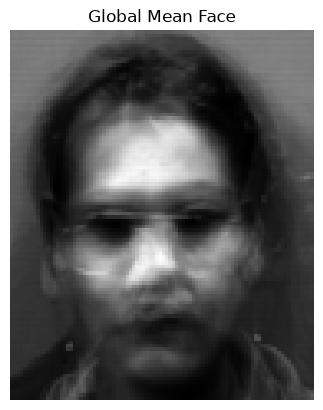

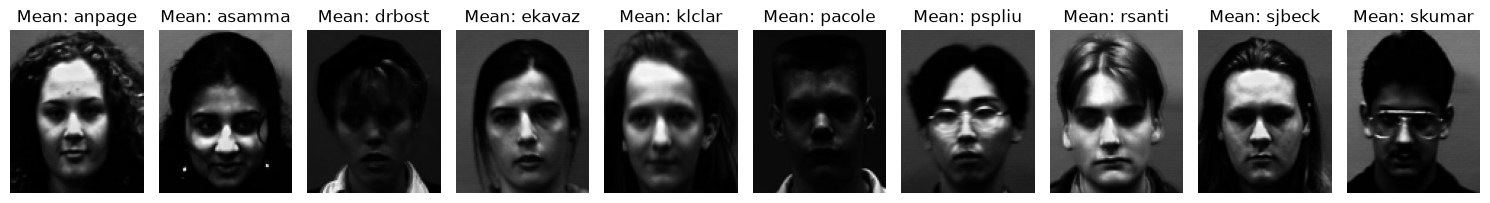

In [4]:
# Centering the faces

# Average face vector for entire training sample
global_mean_face = np.mean(X_train, axis = 0)

# Centering the data matrices
X_train_centered = X_train - global_mean_face
X_test_centered = X_test - global_mean_face

print(f"Shape of mean face vector: {global_mean_face.shape}")
print(f"Shape of testing data after centering: {X_train_centered.shape}")

# Visualizing global mean face
plt.imshow(global_mean_face.reshape(IMG_HEIGHT,IMG_WIDTH), cmap = "gray")
plt.title("Global Mean Face")
plt.axis("off")
plt.show()


# per-person mean faces
unique_people = np.unique(y_train)
person_means = {}

for person in unique_people:
    # Filter training images belonging to this person
    person_images = X_train[y_train == person]
    # Calculating average face for this individual
    person_means[person] = np.mean(person_images, axis = 0)

# Visualizing mean face for each person
plt.figure(figsize=(15, 3))
for i, person in enumerate(unique_people):
    plt.subplot(1, len(unique_people), i + 1)
    plt.imshow(person_means[person].reshape(IMG_HEIGHT, IMG_WIDTH), cmap='gray')
    plt.title(f"Mean: {person}")
    plt.axis('off')
plt.tight_layout()
plt.show()

Matrix A shape: (10304, 40)
U shape: (10304, 40), S shape: (40,), Vt shape: (40, 40)
Retained eigenfaces shape: (10304, 20)


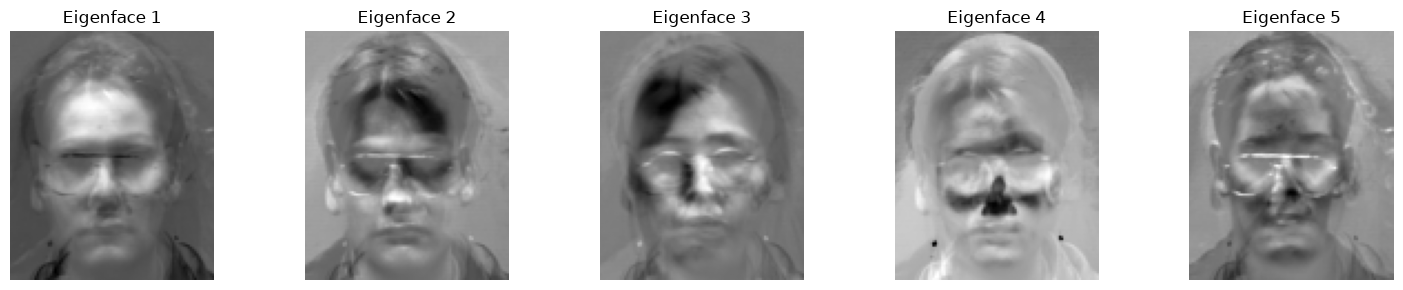

In [10]:
# Dimensionality reduction via SVD

A = X_train_centered.T

# comptuting the SVD (A = U*sigma*Vt)
U, S, Vt = svd(A, full_matrices = False)

# We will keep the top 20 eigenfaces since they capture the more than 90% of the variance
M_prime = 20
eigenfaces = U[:, :M_prime] #shape = N^2 X M_prime

print(f"Matrix A shape: {A.shape}")
print(f"U shape: {U.shape}, S shape: {S.shape}, Vt shape: {Vt.shape}")
print(f"Retained eigenfaces shape: {eigenfaces.shape}")

# Visualizing the top 5 eigenfaces
plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    # Reshape column vector back to 2D image
    plt.imshow(eigenfaces[:, i].reshape(IMG_HEIGHT, IMG_WIDTH), cmap='gray')
    plt.title(f"Eigenface {i + 1}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Extracting the feature weight vectors

